In [7]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd


In [ ]:
# Load the GeoPackage (Coastal Vulnerability Data)
gpkg_path = "../../data/EMODNET/coastal_type/EMODnetCoastalType.gpkg"
gdf = gpd.read_file(gpkg_path)

# Convert CRS to EPSG:4326 (lat/lon)
gdf = gdf.to_crs(epsg=4326)

In [ ]:
path = "/Users/lb962/Downloads/EMODnet_Bathymetry_2024_coastlines/Europe_2024_OSM/Coastline_Europe_2024_OSM.shp"

In [ ]:
gdf.LAYER.unique()

array(['Unknown Area Type'], dtype=object)

               LAYER  FID  Shape_Leng  Shape_Area  \
0  Unknown Area Type  0.0         NaN         NaN   
1  Unknown Area Type  1.0         NaN         NaN   
2  Unknown Area Type  2.0         NaN         NaN   
3  Unknown Area Type  3.0         NaN         NaN   
4  Unknown Area Type  4.0         NaN         NaN   

                                            geometry  
0  POLYGON ((-4.94237 55.72545, -4.94192 55.72558...  
1  POLYGON ((-4.94051 55.72458, -4.94049 55.72407...  
2  POLYGON ((-4.7329 55.52496, -4.7338 55.52495, ...  
3  POLYGON ((-4.95385 55.1629, -4.95388 55.16341,...  
4  POLYGON ((-1.75363 50.72293, -1.75358 50.72303...  
EPSG:4326


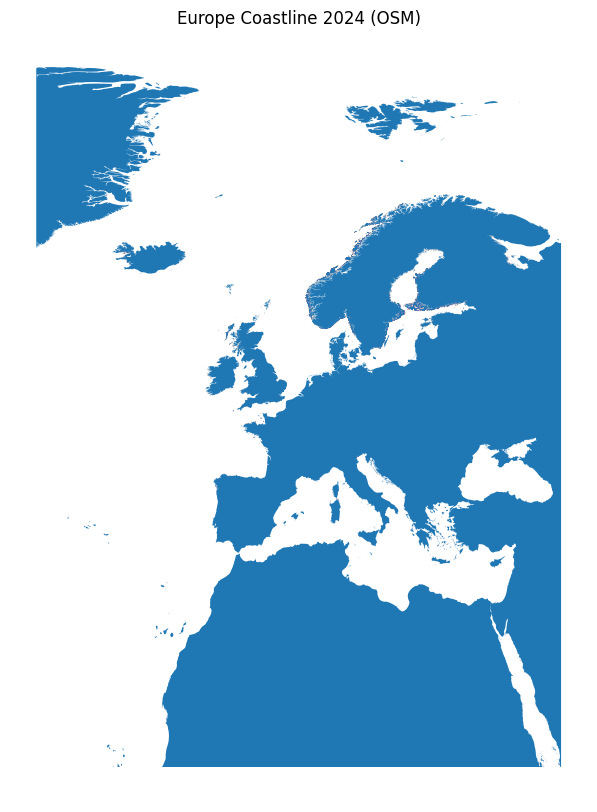

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Path to your shapefile
path = "/Users/lb962/Downloads/EMODnet_Bathymetry_2024_coastlines/Europe_2024_OSM/Coastline_Europe_2024_OSM.shp"

# Read shapefile
gdf = gpd.read_file(path)

# Quick inspection
print(gdf.head())
print(gdf.crs)

# Plot
fig, ax = plt.subplots(figsize=(10, 10))
gdf.plot(ax=ax, linewidth=0.5)

ax.set_title("Europe Coastline 2024 (OSM)")
ax.set_axis_off()

plt.show()

In [2]:
! pip install fiona

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.8/14.8 MB 702.8 kB/s eta 0:00:0000:0100:01


In [6]:
import fiona
import geopandas as gpd
gpkg_path = "/Users/lb962/Downloads/Results 2/CZ_2018_DU004_3035_V010/Data/CZ_2018_DU004_3035_V010.gpkg"
layers = fiona.listlayers(gpkg_path)
print(layers)

['CZ_2018_DU004_3035_V010']


In [ ]:
gdf = gpd.read_file(gpkg_path, layer="CZ_2018_DU004_3035_V010")

In [1]:
import geopandas as gpd
# Load the GeoPackage (Coastal Type from Copernicus Land)
gpkg_path = "/Users/lb962/Downloads/Results 2/CZ_2018_DU004_3035_V010/Data/CZ_2018_DU004_3035_V010.gpkg"
gdf = gpd.read_file(gpkg_path)

# Convert CRS to EPSG:4326 (lat/lon)
#gdf = gdf.to_crs(epsg=4326)

: 

: 

# EMODNET Coastal Type

In [8]:
import geopandas as gpd
import rasterio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from rasterio.transform import from_origin

# Load the GeoPackage (Coastal Vulnerability Data)
gpkg_path = "../../data/EMODNET/coastal_type/EMODnetCoastalType.gpkg"
gdf = gpd.read_file(gpkg_path)

# Convert CRS to EPSG:4326 (lat/lon)
gdf = gdf.to_crs(epsg=4326)

# Check geometry type and assign latitude and longitude based on the geometry type
if gdf.geometry.geom_type.iloc[0] == 'Point':
    gdf['latitude'] = gdf.geometry.y
    gdf['longitude'] = gdf.geometry.x
else:
    # If it's not a point, calculate the centroid for non-Point geometries
    gdf['latitude'] = gdf.geometry.centroid.y
    gdf['longitude'] = gdf.geometry.centroid.x

# Load raster data (Wave and Current)
def load_raster_data(raster_path):
    with rasterio.open(raster_path) as raster:
        raster_data = raster.read(1)  # Read the first band
        transform = raster.transform  # Affine transform
        crs = raster.crs  # Coordinate reference system
        bounds = raster.bounds  # Get the bounds (min, max)
    return raster_data, transform, crs, bounds

# Paths to wave and current rasters
wave_raster_path_NC = "../../data/EMODNET/ke_waves_NC_withconf/ke_waves_NC_conf.tif"
wave_raster_path_atlantic = "../../data/EMODNET/ke_waves_NC_withconf/ke_waves_atlantic.tif"
current_raster_path = "../../data/EMODNET/ke_currents_atlantic_withconf/ke_currents_atlantic.tif"

# Load all raster data
wave_nc_data, wave_nc_transform, wave_nc_crs, wave_nc_bounds = load_raster_data(wave_raster_path_NC)
wave_atlantic_data, wave_atlantic_transform, wave_atlantic_crs, wave_atlantic_bounds = load_raster_data(wave_raster_path_atlantic)
current_data, current_transform, current_crs, current_bounds = load_raster_data(current_raster_path)

# Generate a grid of latitudes and longitudes for the raster data
def generate_lat_lon_grid(raster_data, raster_transform):
    rows, cols = raster_data.shape
    lon, lat = np.meshgrid(
        np.linspace(raster_transform[2], raster_transform[2] + raster_transform[0] * cols, cols),
        np.linspace(raster_transform[5] + raster_transform[4] * rows, raster_transform[5], rows)
    )
    return lat, lon

# Generate lat/lon grids for each raster
wave_nc_lat, wave_nc_lon = generate_lat_lon_grid(wave_nc_data, wave_nc_transform)
wave_atlantic_lat, wave_atlantic_lon = generate_lat_lon_grid(wave_atlantic_data, wave_atlantic_transform)
current_lat, current_lon = generate_lat_lon_grid(current_data, current_transform)

# Create DataFrame for wave and current data with latitude/longitude
def create_raster_df(lat, lon, data, variable_name):
    df = pd.DataFrame({
        'latitude': lat.flatten(),
        'longitude': lon.flatten(),
        variable_name: data.flatten()
    })
    return df

# Create DataFrames for wave and current data
wave_nc_df = create_raster_df(wave_nc_lat, wave_nc_lon, wave_nc_data, 'Wave_NC')
wave_atlantic_df = create_raster_df(wave_atlantic_lat, wave_atlantic_lon, wave_atlantic_data, 'Wave_Atlantic')
current_df = create_raster_df(current_lat, current_lon, current_data, 'Current')

/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/pyogrio/geopandas.py:265: UserWarning: More than one layer found in 'EMODnetCoastalType.gpkg': 'Original' (default), '02', '2', '005', '05', '015', '0025', '01', '1', 'layer_styles'. Specify layer parameter to avoid this warning.
  result = read_func(
/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_58457/2086513627.py:21: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['latitude'] = gdf.geometry.centroid.y
/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_58457/2086513627.py:22: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['longitude'] = gdf.geometry.centroid.x


In [21]:
import numpy as np
import geopandas as gpd

CVI_gdf = gpd.read_file("../../data/EMODNET/coastal_vulnerability_resilience/20241218_original.gpkg")

# If CRS missing, set it (EMODnet often uses EPSG:3035)
if CVI_gdf.crs is None:
    CVI_gdf = CVI_gdf.set_crs(epsg=3035)

# Drop empties
CVI_gdf = CVI_gdf[~CVI_gdf.geometry.is_empty & CVI_gdf.geometry.notna()].copy()

# Fix invalid geometries (lines can still be "invalid")
CVI_gdf["geometry"] = CVI_gdf.geometry.make_valid()

# Reproject to lat/lon for Cartopy
CVI_gdf = CVI_gdf.to_crs(epsg=4326)

# (Optional but useful) remove any geometries with non-finite bounds
minx, miny, maxx, maxy = CVI_gdf.total_bounds
print("Bounds:", CVI_gdf.total_bounds)



Bounds: [-31.26757026   4.30520622  42.00064128  80.50602762]


In [ ]:
GEV_clusters = pd.read_csv("/Users/lb962/Documents/GitHub/ESL_stats/notebooks/C_KDE/station_GEV_7.csv")
GEV_clusters["station"] = GEV_clusters["station"].astype(int)

In [23]:
import geopandas as gpd

def clean_for_sjoin(gdf):
    # Remove leftover join columns that break future joins
    return gdf.drop(columns=["index_right", "index_left"], errors="ignore")

def to_proj(gdf, epsg=3857):
    # Ensure CRS exists
    if gdf.crs is None:
        raise ValueError("GeoDataFrame has no CRS set. Set it before projecting.")
    return gdf.to_crs(epsg=epsg)
PROJECTED_EPSG = 3857


In [24]:
GEV_gdf = gpd.GeoDataFrame(
    GEV_clusters.copy(),
    geometry=gpd.points_from_xy(GEV_clusters["lon"], GEV_clusters["lat"]),
    crs="EPSG:4326"
)

GEV_proj = GEV_gdf.to_crs(epsg=PROJECTED_EPSG)
GEV_proj = clean_for_sjoin(GEV_proj)


In [36]:
CVI_proj = clean_for_sjoin(CVI_gdf.to_crs(epsg=PROJECTED_EPSG))

GEV_all = gpd.sjoin_nearest(
    GEV_proj,
    CVI_proj[["CVI_Category", "geometry"]],
    how="left",
    distance_col="dist_to_CVI_m"
).drop(columns=["index_right"], errors="ignore")
morpho_proj = clean_for_sjoin(gdf)
morpho_proj = morpho_proj.to_crs(epsg=PROJECTED_EPSG)

GEV_all = gpd.sjoin_nearest(
    GEV_all,
    morpho_proj[["Morpho", "CoastType", "geometry"]],
    how="left",
    distance_col="dist_to_morpho_m"
).drop(columns=["index_right"], errors="ignore")


In [47]:
import geopandas as gpd

# Ensure lon/lat CRS for Cartopy
if GEV_all.crs is None:
    raise ValueError("GEV_all has no CRS. Set it (likely EPSG:4326) before plotting.")
GEV_all = GEV_all.to_crs(epsg=4326)


In [48]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.cm import get_cmap

def extent_from_gdf(gdf, pad_deg=2.0):
    minx, miny, maxx, maxy = gdf.total_bounds
    return [minx - pad_deg, maxx + pad_deg, miny - pad_deg, maxy + pad_deg]

def plot_categorical_cartopy(
    gdf,
    col,
    title=None,
    extent=None,
    s=28,
    max_legend_items=20
):
    g = gdf[gdf[col].notna()].copy()
    if len(g) == 0:
        raise ValueError(f"No non-null values found in column '{col}'.")
    extent=[-20,15,48,65]
    #if extent is None:
       # extent = extent_from_gdf(g)

    categories = sorted(g[col].astype(str).unique())
    n = len(categories)

    # Use a colormap with many distinct colors
    cmap = get_cmap("tab20" if n <= 20 else "tab20b" if n <= 40 else "hsv")
    colors = {cat: cmap(i / max(1, n - 1)) for i, cat in enumerate(categories)}

    fig = plt.figure(figsize=(12, 9))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent(extent, crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6, zorder=1)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3, zorder=1)

    # Plot each category separately (so legend works)
    for cat in categories:
        sub = g[g[col].astype(str) == cat]
        ax.scatter(
            sub.geometry.x, sub.geometry.y,
            s=s,
            color=colors[cat],
            edgecolor="black",
            linewidth=0.2,
            label=cat,
            transform=ccrs.PlateCarree(),
            zorder=3
        )

    gl = ax.gridlines(draw_labels=True, linewidth=0.3, linestyle="--")
    gl.top_labels = False
    gl.right_labels = False

    ax.set_title(title or f"GEV_all coloured by {col}")

    # Legend handling (CoastType can have loads)
    if n <= max_legend_items:
        ax.legend(title=col, loc="lower left")
    else:
        # Too many categories: show counts instead of an unreadable legend
        counts = g[col].astype(str).value_counts()
        txt = "\n".join([f"{k}: {v}" for k, v in counts.head(max_legend_items).items()])
        txt += f"\n… +{n - max_legend_items} more"
        ax.text(
            0.01, 0.01, txt,
            transform=ax.transAxes,
            fontsize=9,
            va="bottom",
            bbox=dict(facecolor="white", alpha=0.8, edgecolor="none")
        )

    plt.tight_layout()
    plt.show()


In [79]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.cm import get_cmap

def plot_cartopy(
    gdf,
    col,
    kind="categorical",        # "categorical" | "continuous"
    title=None,
    extent=[-20, 15, 48, 65],
    s=28,
    max_legend_items=20,
    cmap_cont="viridis",
    robust=True
):
    g = gdf[gdf[col].notna()].copy()
    if len(g) == 0:
        raise ValueError(f"No non-null values found in column '{col}'.")

    fig = plt.figure(figsize=(12, 9))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent(extent, crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6, zorder=1)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3, zorder=1)

    # ---------------------------
    # CATEGORICAL
    # ---------------------------
    if kind == "categorical":
        categories = sorted(g[col].astype(str).unique())
        n = len(categories)

        cmap = get_cmap("tab20" if n <= 20 else "tab20b" if n <= 40 else "hsv")
        colors = {cat: cmap(i / max(1, n - 1)) for i, cat in enumerate(categories)}

        for cat in categories:
            sub = g[g[col].astype(str) == cat]
            ax.scatter(
                sub.geometry.x, sub.geometry.y,
                s=s,
                color=colors[cat],
                edgecolor="black",
                linewidth=0.2,
                label=cat,
                transform=ccrs.PlateCarree(),
                zorder=3
            )

        if n <= max_legend_items:
            ax.legend(title=col, loc="lower left")
        else:
            counts = g[col].astype(str).value_counts()
            txt = "\n".join([f"{k}: {v}" for k, v in counts.head(max_legend_items).items()])
            txt += f"\n… +{n - max_legend_items} more"
            ax.text(
                0.01, 0.01, txt,
                transform=ax.transAxes,
                fontsize=9,
                va="bottom",
                bbox=dict(facecolor="white", alpha=0.8, edgecolor="none")
            )

    # ---------------------------
    # CONTINUOUS
    # ---------------------------
    elif kind == "continuous":
        values = g[col].astype(float)

        if robust:
            vmin, vmax = np.nanpercentile(values, [2, 98])
        else:
            vmin, vmax = np.nanmin(values), np.nanmax(values)

        sc = ax.scatter(
            g.geometry.x, g.geometry.y,
            c=values,
            s=s,
            cmap=cmap_cont,
            vmin=vmin,
            vmax=vmax,
            edgecolor="black",
            linewidth=0.2,
            transform=ccrs.PlateCarree(),
            zorder=3
        )

        cb = plt.colorbar(sc, ax=ax, shrink=0.75)
        cb.set_label(col)

    else:
        raise ValueError("kind must be 'categorical' or 'continuous'")

    gl = ax.gridlines(draw_labels=True, linewidth=0.3, linestyle="--")
    gl.top_labels = False
    gl.right_labels = False

    ax.set_title(title or f"GEV_all coloured by {col}")
    plt.tight_layout()
    plt.show()


/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_58457/2370617341.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap("tab20" if n <= 20 else "tab20b" if n <= 40 else "hsv")


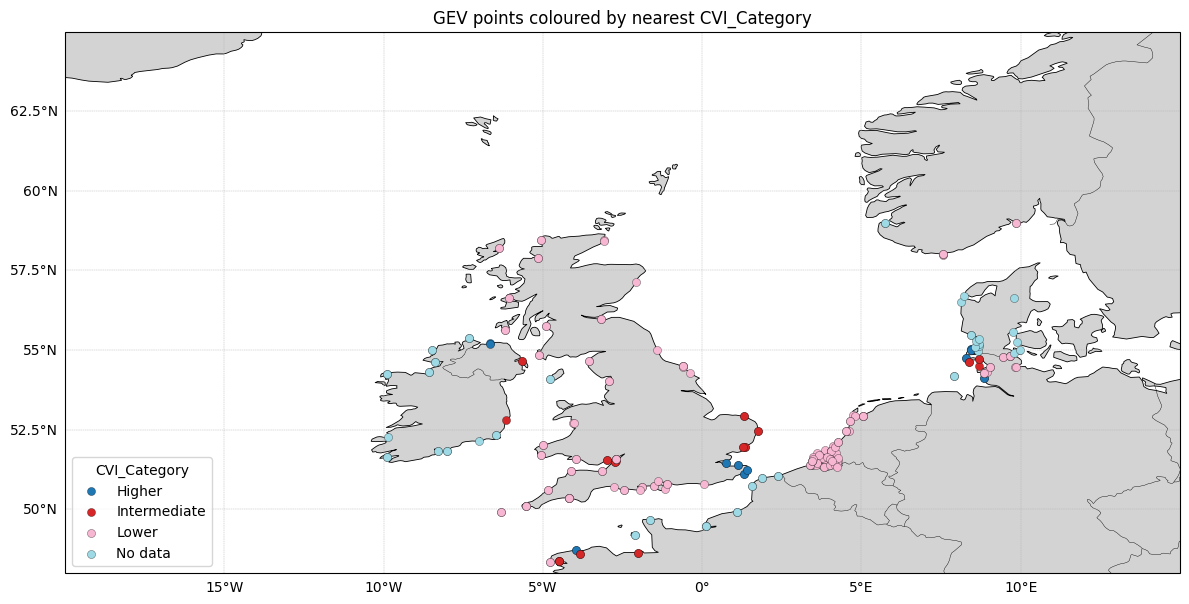

In [82]:
plot_cartopy(
    GEV_all,
    col="CVI_Category",
    title="GEV points coloured by nearest CVI_Category",
    s=34
)


/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_58457/2370617341.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap("tab20" if n <= 20 else "tab20b" if n <= 40 else "hsv")


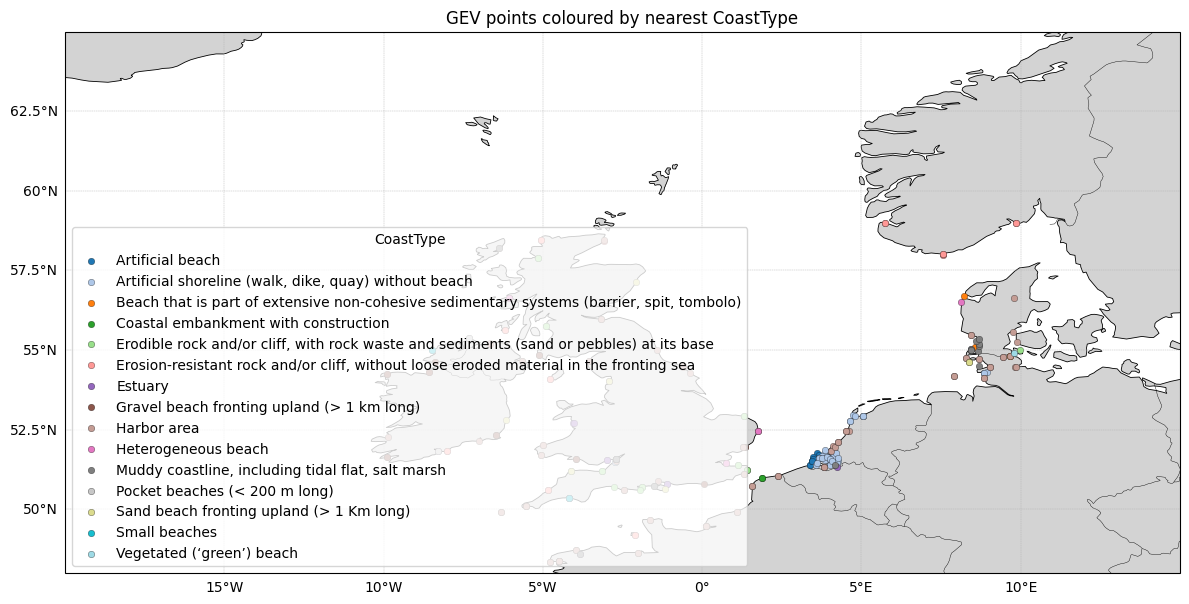

In [83]:
plot_cartopy(
    GEV_all,
    col="CoastType",
    title="GEV points coloured by nearest CoastType",
    s=22,
    max_legend_items=20
)


/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_58457/2370617341.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap("tab20" if n <= 20 else "tab20b" if n <= 40 else "hsv")


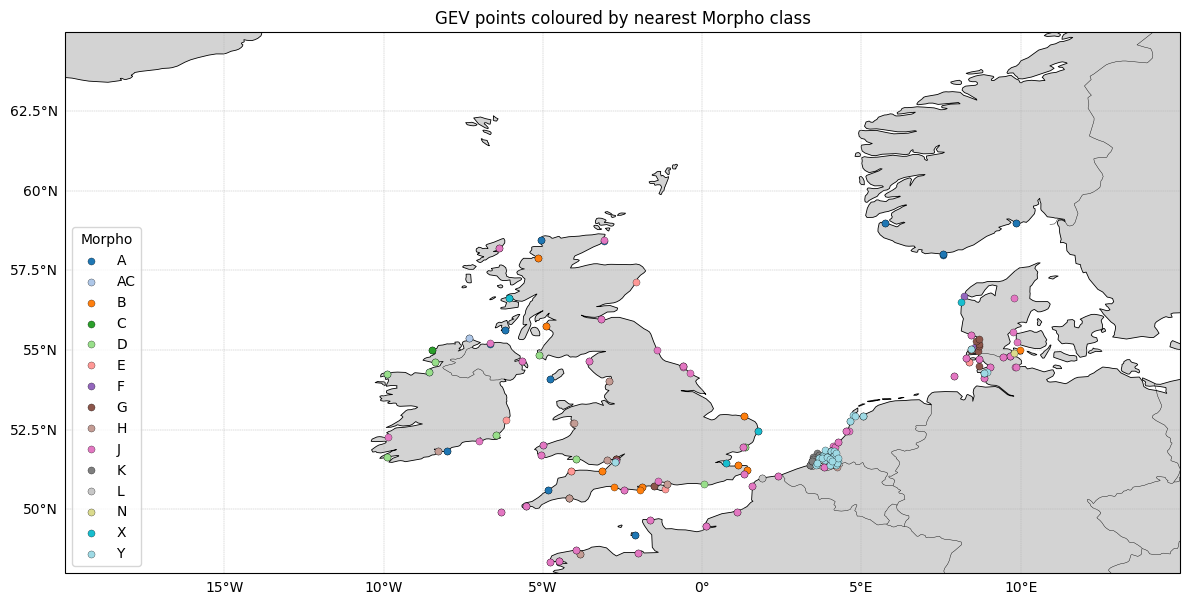

In [84]:
plot_cartopy(
    GEV_all,
    col="Morpho",
    title="GEV points coloured by nearest Morpho class",
    s=26,
    max_legend_items=20
)


In [ ]:
print(hallo)

In [52]:
import numpy as np
import rasterio
from rasterio.windows import from_bounds

def add_raster_mean_box(
    points_gdf,
    raster_path,
    out_col,
    half_size_deg=0.1,
    nodata_absurd=1e10
):
    """
    Adds column `out_col` to points_gdf: mean raster value within a box
    (lon±half_size_deg, lat±half_size_deg) around each point.

    Assumes points are EPSG:4326 if raster is EPSG:4326. If raster CRS differs,
    points are reprojected to raster CRS and the half-size is interpreted in raster units.
    """
    with rasterio.open(raster_path) as src:
        # Reproject points to raster CRS (required)
        if points_gdf.crs != src.crs:
            pts = points_gdf.to_crs(src.crs)
        else:
            pts = points_gdf

        nodata = src.nodata
        results = np.full(len(pts), np.nan, dtype=float)

        # Iterate points (fast enough for a few thousand points)
        for i, geom in enumerate(pts.geometry):
            if geom is None or geom.is_empty:
                continue

            x, y = geom.x, geom.y

            # Define bounds of the box
            left   = x - half_size_deg
            right  = x + half_size_deg
            bottom = y - half_size_deg
            top    = y + half_size_deg

            # Build window in raster pixel coordinates
            try:
                win = from_bounds(left, bottom, right, top, transform=src.transform)
            except Exception:
                continue

            # Read raster window
            arr = src.read(1, window=win, masked=False)

            # Convert to float + mask nodata/absurd
            arr = arr.astype(float)

            if nodata is not None:
                arr[arr == nodata] = np.nan

            arr[np.abs(arr) > nodata_absurd] = np.nan

            # Compute mean
            if np.isfinite(arr).any():
                results[i] = np.nanmean(arr)

        # Attach back to original gdf (aligned by row order)
        points_gdf[out_col] = results

    return points_gdf


In [66]:
import numpy as np
import rasterio
from rasterio.windows import from_bounds

def add_raster_mean_box(
    points_gdf,
    raster_path,
    out_col,
    half_size_deg=0.1,
    nodata_absurd=1e10   # <-- ONLY threshold used
):
    with rasterio.open(raster_path) as src:
        pts = points_gdf.to_crs(src.crs) if points_gdf.crs != src.crs else points_gdf

        nodata = src.nodata
        results = np.full(len(pts), np.nan, dtype=float)

        for i, geom in enumerate(pts.geometry):
            if geom is None or geom.is_empty:
                continue

            x, y = geom.x, geom.y
            left, right = x - half_size_deg, x + half_size_deg
            bottom, top = y - half_size_deg, y + half_size_deg

            try:
                win = from_bounds(left, bottom, right, top, transform=src.transform)
            except Exception:
                continue

            arr = src.read(1, window=win, masked=False).astype(float)

            # mask raster nodata
            if nodata is not None:
                arr[arr == nodata] = np.nan

            # ✅ mask absurd fill values ONLY
            arr[np.abs(arr) > nodata_absurd] = np.nan

            if np.isfinite(arr).any():
                results[i] = np.nanmean(arr)

        points_gdf[out_col] = results

    return points_gdf


In [67]:
GEV_all = add_raster_mean_box(
    GEV_all,
    wave_raster_path_NC,
    out_col="wave_nc_mean_0p1deg",
    half_size_deg=0.1
)

GEV_all = add_raster_mean_box(
    GEV_all,
    wave_raster_path_atlantic,
    out_col="wave_atl_mean_0p1deg",
    half_size_deg=0.1
)


In [70]:
import rasterio
with rasterio.open(current_raster_path) as src:
    print("Raster CRS:", src.crs)


Raster CRS: None


In [87]:
import numpy as np
import rasterio
from rasterio.windows import from_bounds

def add_raster_mean_box(
    points_gdf,
    raster_path,
    out_col,
    half_size_deg=0.1,
    nodata_absurd=1e5,
    raster_epsg_if_missing=4326  # ✅ fallback
):
    with rasterio.open(raster_path) as src:
        raster_crs = src.crs
        if raster_crs is None:
            raster_crs = f"EPSG:{raster_epsg_if_missing}"

        pts = points_gdf.to_crs(raster_crs) if points_gdf.crs != raster_crs else points_gdf

        nodata = src.nodata
        results = np.full(len(pts), np.nan, dtype=float)

        for i, geom in enumerate(pts.geometry):
            if geom is None or geom.is_empty:
                continue

            x, y = geom.x, geom.y
            left, right = x - half_size_deg, x + half_size_deg
            bottom, top = y - half_size_deg, y + half_size_deg

            try:
                win = from_bounds(left, bottom, right, top, transform=src.transform)
            except Exception:
                continue

            arr = src.read(1, window=win, masked=False).astype(float)

            if nodata is not None:
                arr[arr == nodata] = np.nan

            arr[np.abs(arr) > nodata_absurd] = np.nan

            if np.isfinite(arr).any():
                results[i] = np.nanmean(arr)

        points_gdf[out_col] = results

    return points_gdf


In [88]:
GEV_all = add_raster_mean_box(GEV_all, current_raster_path, "current_mean_0p1deg", half_size_deg=0.1)
GEV_all = add_raster_mean_box(GEV_all, current_raster_path, "current_mean_1deg",   half_size_deg=1.0)


In [89]:
GEV_all = add_raster_mean_box(
    GEV_all,
    current_raster_path,
    out_col="current_mean_0p1deg",
    half_size_deg=0.1
)

GEV_all = add_raster_mean_box(
    GEV_all,
    current_raster_path,
    out_col="current_mean_1deg",
    half_size_deg=1.0
)


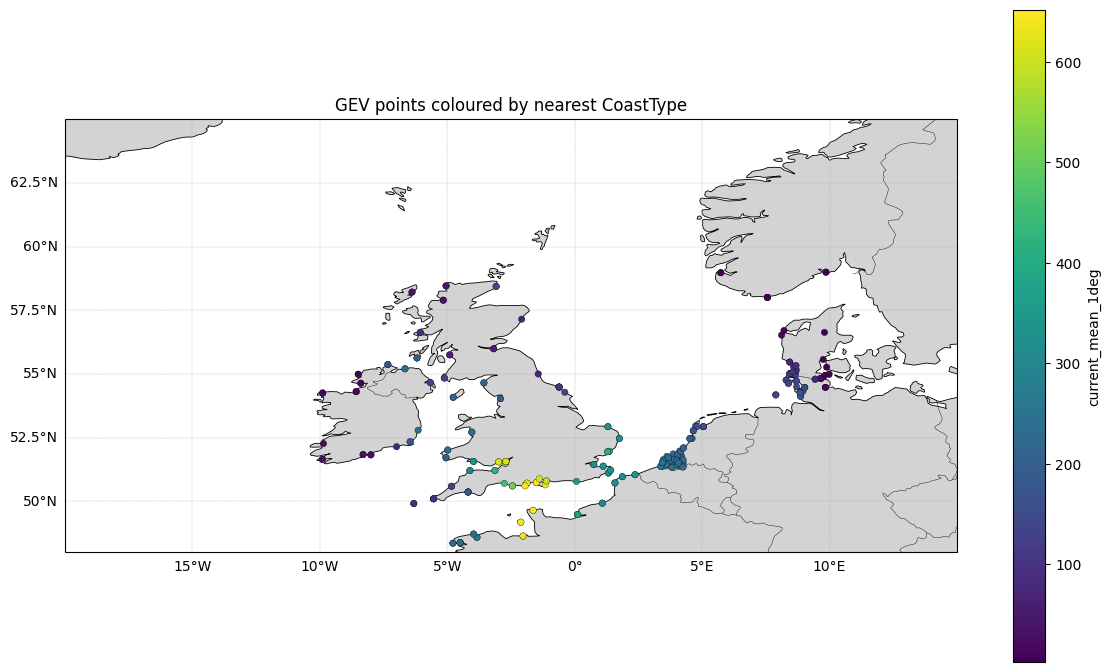

In [90]:
plot_cartopy(
    GEV_all,
    kind='continuous',
    col="current_mean_1deg",
    title="GEV points coloured by nearest CoastType",
    s=22,
    max_legend_items=20
)


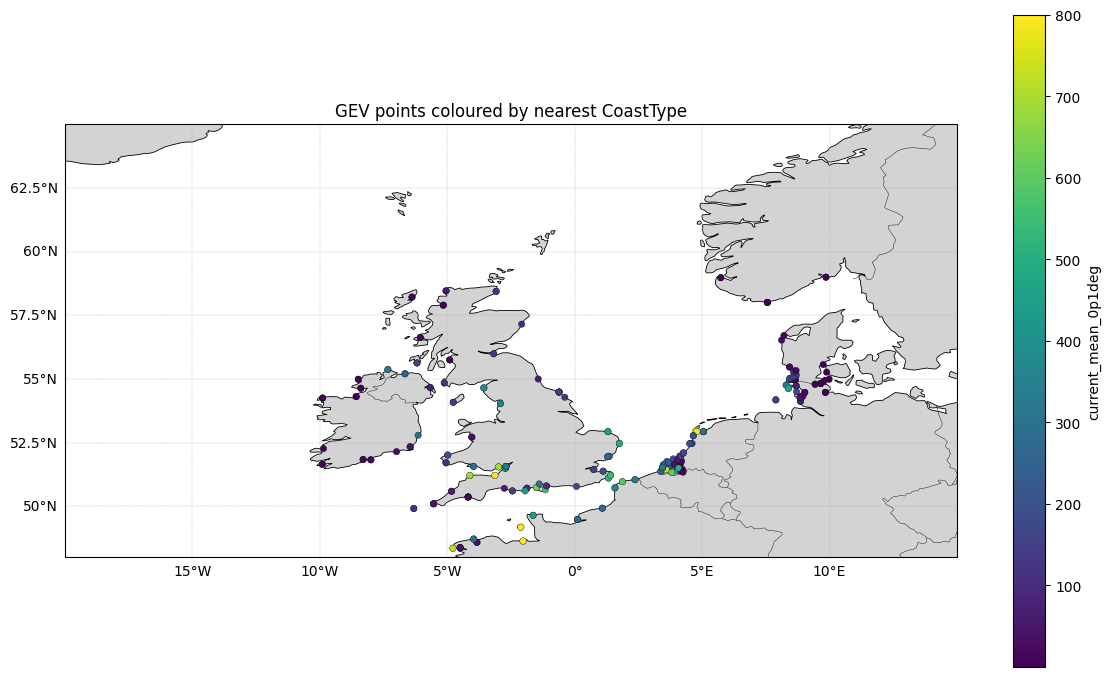

In [91]:
plot_cartopy(
    GEV_all,
    kind="continuous",
    col="current_mean_0p1deg",
    title="GEV points coloured by nearest CoastType",
    s=22,
    max_legend_items=0
)


In [95]:
import geopandas as gpd

gdb_path = "/Users/lb962/Downloads/HydroRIVERS_v10_eu.gdb/HydroRIVERS_v10_eu.gdb"
print(gpd.list_layers(gdb_path))  # see available layers

rivers = gpd.read_file(gdb_path)  # or layer="HydroRIVERS_v10_eu" etc.
print(rivers.columns)


                 name    geometry_type
0  HydroRIVERS_v10_eu  MultiLineString
Index(['HYRIV_ID', 'NEXT_DOWN', 'MAIN_RIV', 'LENGTH_KM', 'DIST_DN_KM',
       'DIST_UP_KM', 'CATCH_SKM', 'UPLAND_SKM', 'ENDORHEIC', 'DIS_AV_CMS',
       'ORD_STRA', 'ORD_CLAS', 'ORD_FLOW', 'HYBAS_L12', 'Shape_Length',
       'geometry'],
      dtype='object')


In [96]:
outlets = rivers[rivers["NEXT_DOWN"] == 0].copy()

if "ENDORHEIC" in outlets.columns:
    outlets = outlets[outlets["ENDORHEIC"] == 0].copy()  # keep ocean outlets only


In [97]:
from shapely.geometry import Point

def downstream_point(line):
    coords = list(line.coords)
    return Point(coords[-1])

# If MultiLineString, take the longest part (simple heuristic)
def downstream_point_any(geom):
    if geom.geom_type == "LineString":
        return downstream_point(geom)
    if geom.geom_type == "MultiLineString":
        part = max(list(geom.geoms), key=lambda g: g.length)
        return downstream_point(part)
    return None

outlets = outlets[outlets.geometry.notna() & ~outlets.geometry.is_empty].copy()
outlets["geometry"] = outlets.geometry.apply(downstream_point_any)
outlets = outlets[outlets.geometry.notna()].copy()
outlets = outlets.set_geometry("geometry")


In [ ]:
PROJECTED_EPSG = 3035  # good for Europe; use 3857 if your domain is broader

GEV_proj = GEV_all.to_crs(epsg=PROJECTED_EPSG)
outlets_proj = outlets.to_crs(epsg=PROJECTED_EPSG)

GEV_with_outlet = gpd.sjoin_nearest(
    GEV_proj,
    outlets_proj[["HYRIV_ID", "geometry"]],
    how="left",
    distance_col="dist_to_river_outlet_m"
).drop(columns=["index_right"], errors="ignore")

GEV_with_outlet = GEV_with_outlet.to_crs(epsg=4326)

In [99]:
rivers_proj = rivers.to_crs(epsg=PROJECTED_EPSG)
GEV_proj = GEV_all.to_crs(epsg=PROJECTED_EPSG)

GEV_on_river = gpd.sjoin_nearest(
    GEV_proj,
    rivers_proj[["HYRIV_ID", "DIST_DN_KM", "geometry"]],
    how="left",
    distance_col="dist_to_nearest_reach_m"
).drop(columns=["index_right"], errors="ignore")

GEV_on_river["downstream_to_outlet_km"] = GEV_on_river["DIST_DN_KM"]
GEV_on_river = GEV_on_river.to_crs(epsg=4326)


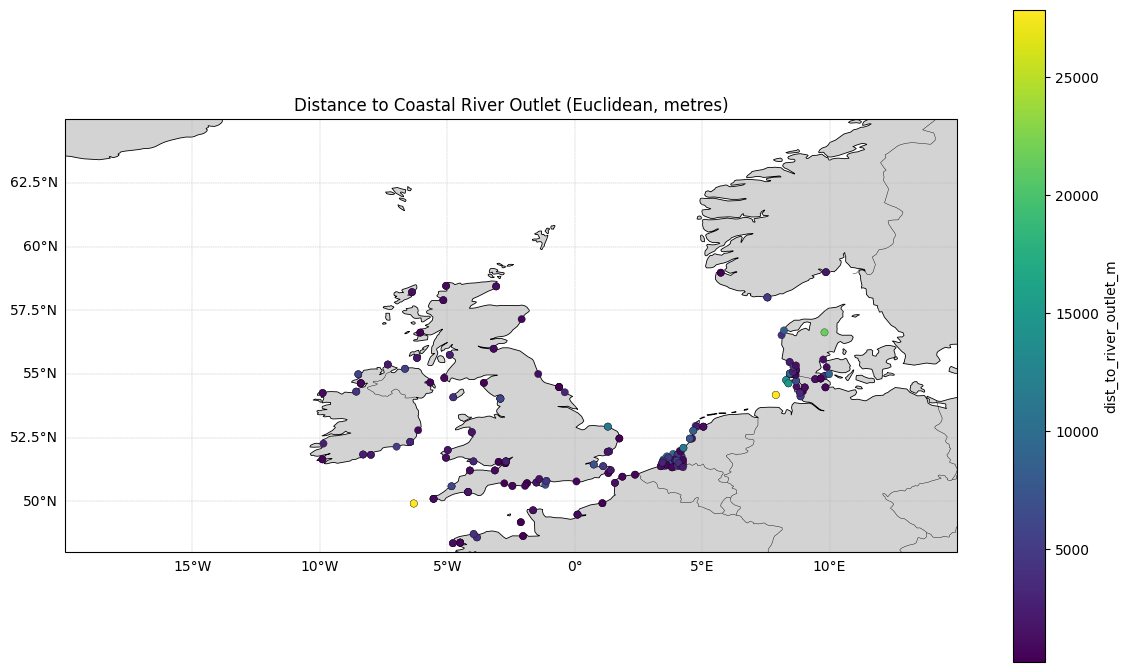

In [101]:
plot_cartopy(
    GEV_with_outlet,
    kind="continuous",
    col="dist_to_river_outlet_m",
    title="Distance to Coastal River Outlet (Euclidean, metres)",
)


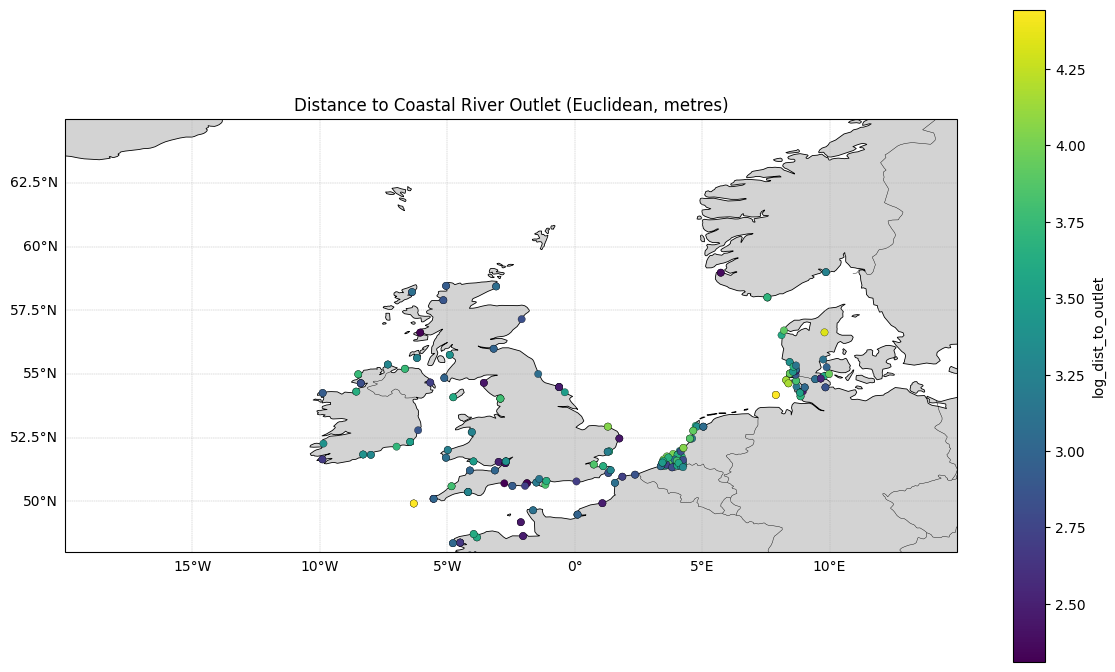

In [107]:
GEV_with_outlet["log_dist_to_outlet"] = np.log10(
    GEV_with_outlet["dist_to_river_outlet_m"] + 1
)

plot_cartopy(
    GEV_with_outlet,
    kind="continuous",
    col="log_dist_to_outlet",
    title="Distance to Coastal River Outlet (Euclidean, metres)",
)

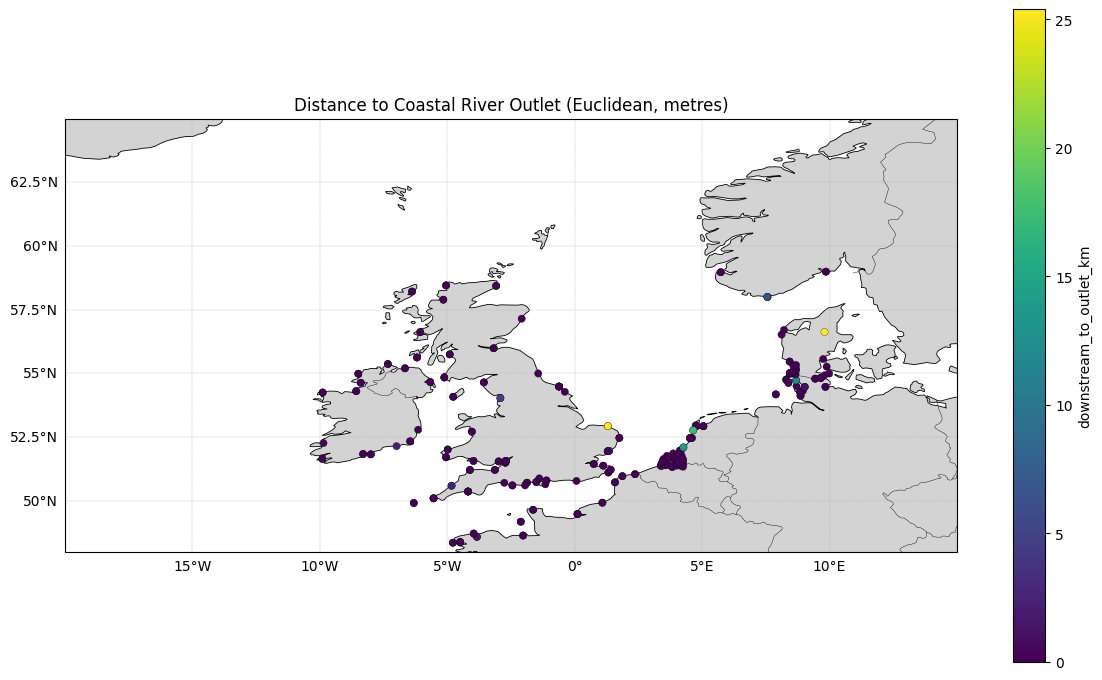

In [105]:
plot_cartopy(
    GEV_on_river,
    kind="continuous",
    col="downstream_to_outlet_km",
    title="Distance to Coastal River Outlet (Euclidean, metres)",
)


In [111]:
# GEV_with_outlet came from joining OUTLETS onto GEV_all (left = GEV_all)
cols_to_add = ["dist_to_river_outlet_m"]
if "downstream_to_outlet_km" in GEV_with_outlet.columns:
    cols_to_add.append("downstream_to_outlet_km")

GEV_all = GEV_all.join(GEV_with_outlet[cols_to_add])


In [112]:
import numpy as np
import geopandas as gpd

# ---- settings ----
PROJECTED_EPSG = 3035
MAX_DIST_M = 10_000  # 10 km

# ---- ensure stable ID (recommended once) ----
GEV_all = GEV_all.copy()
if "GEV_ID" not in GEV_all.columns:
    GEV_all["GEV_ID"] = np.arange(len(GEV_all))

# ---- project to metres for distance computations ----
GEV_proj = GEV_all.to_crs(epsg=PROJECTED_EPSG)
rivers_proj = rivers.to_crs(epsg=PROJECTED_EPSG)

# ---- avoid sjoin column collisions from previous joins ----
GEV_proj = GEV_proj.drop(columns=["index_right", "index_left"], errors="ignore")
rivers_proj = rivers_proj.drop(columns=["index_right", "index_left"], errors="ignore")

# ---- nearest river reach join ----
nearest_riv = gpd.sjoin_nearest(
    GEV_proj,
    rivers_proj[["HYRIV_ID", "DIS_AV_CMS", "CATCH_SKM", "DIST_DN_KM", "geometry"]],
    how="left",
    distance_col="dist_to_nearest_river_m"
).drop(columns=["index_right"], errors="ignore")

# ---- apply 10 km condition ----
within10 = nearest_riv["dist_to_nearest_river_m"] <= MAX_DIST_M

# Catchment area only if within 10 km
nearest_riv["nearest_CATCH_SKM_10km"] = np.where(within10, nearest_riv["CATCH_SKM"], np.nan)

# (Optional) keep discharge too (useful for RiverIndex)
nearest_riv["nearest_DIS_AV_CMS_10km"] = np.where(within10, nearest_riv["DIS_AV_CMS"], np.nan)

# ---- RiverIndex definition ----
# Preferred denominator: your previously computed Euclidean distance to coastal outlet (in metres)
# Fallback: use DIST_DN_KM (along-network km) if dist_to_river_outlet_m isn't in your table yet
if "dist_to_river_outlet_m" in nearest_riv.columns:
    denom_km = (nearest_riv["dist_to_river_outlet_m"] / 1000.0) + 1.0
else:
    denom_km = nearest_riv["DIST_DN_KM"] + 1.0

nearest_riv["river_index_10km"] = np.where(
    within10,
    np.log1p(nearest_riv["DIS_AV_CMS"]) / denom_km,
    np.nan
)

# ---- merge back into GEV_all by GEV_ID ----
cols_back = [
    "GEV_ID",
    "HYRIV_ID",
    "dist_to_nearest_river_m",
    "nearest_CATCH_SKM_10km",
    "nearest_DIS_AV_CMS_10km",
    "river_index_10km"
]

GEV_all = GEV_all.merge(
    nearest_riv[cols_back].drop_duplicates("GEV_ID"),
    on="GEV_ID",
    how="left",
    suffixes=("", "_riv")
)


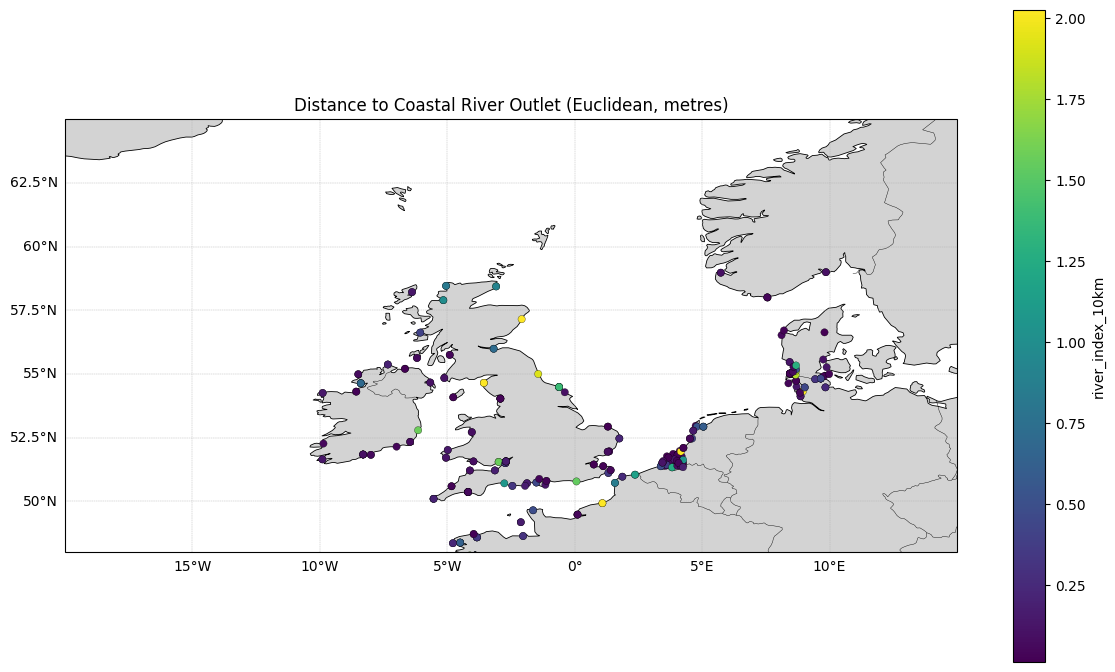

In [ ]:
plot_cartopy(
    GEV_all,
    kind="continuous",
    col="river_index_10km",
    title="River Index",
)

In [119]:
GEV_all.to_csv("/Users/lb962/Documents/GitHub/ESL_stats/notebooks/C_KDE/static_contributers.csv")